# Módulo 7 · Clase 2 — El Tasador: un modelo de punta a punta

**Machine Learning for Petroleum Engineers Using Python** · SLB Ecuador / UDLA

---

### El caso de hoy

**El comprador de diamantes** (nuestro cliente de la Clase 1) compra lotes de
piedras y hoy tasa a ojo, piedra por piedra. Frente a cada una decide
**comprar o pasar**, y comprar caro no se nota hasta vender.

**Lo que nos pidió:** *«un tasador: le meto las medidas de la piedra y me
dice cuánto vale. Que lo use mi gente en la mesa de compra, sin llamarlos a
ustedes».*

Tiene 53.940 compras históricas con precio pagado. Con eso alcanza.

### El mapa de la clase

Un producto de datos, completo, en seis pasos — el mismo flujo en cualquier
empresa:

> **1 Certificar → 2 Entrenar → 3 Examinar → 4 Guardar → 5 Servir → 6 Blindar**

- 🎬 **DEMO:** el tasador, resuelto conmigo de inicio a fin, con los prompts.
- 🛠️ **SU RETO:** el mismo flujo, con otro cliente y otro dato — **la pieza
  central de su proyecto** (equipos de hasta 3, entrega hasta el jueves de
  la próxima semana).

> ⚠️ Como siempre: el reto **no tiene solución escrita** en ninguna parte.
> Se construye en clase.

## 0 · Preparación

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib                        # para guardar y cargar modelos

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score

# los datos del curso
DATOS = "https://raw.githubusercontent.com/cmosquerat/slb-diplomado/main/datos/"

# ¿estamos en Colab? lo usan las celdas de la app
try:
    import google.colab              # noqa: F401
    EN_COLAB = True
except ImportError:
    EN_COLAB = False

SEMILLA = 0                          # misma semilla en TODO: reproducible
print("listo. ¿en Colab?", EN_COLAB)

listo. ¿en Colab? False


---

# 🎬 Paso 1 · Certificar el dato

Nadie entrena con datos que no revisó — es la regla que quedó de la Clase 1
(el cero que no es cero). El prompt que usé:

```
Voy a entrenar un modelo de precios con el DataFrame `diamantes`
(53.940 filas). Columnas: carat, cut, color, clarity, price [USD], y
x, y, z que son las dimensiones físicas de la piedra en milímetros.

ANTES de cualquier modelo: revisión de calidad.
- mínimo, máximo y ceros de cada columna numérica
- dime si algún valor es FÍSICAMENTE imposible para un diamante
  (pista: son milímetros)
- cuántas filas afectadas, y muéstramelas
```

In [2]:
diamantes = pd.read_csv(DATOS + "diamantes.csv")
print(f"{len(diamantes)} piedras")

# la revision que devolvio el agente, resumida a lo esencial
print("\nminimos y maximos de las dimensiones [mm]:")
print(diamantes[["x", "y", "z"]].agg(["min", "max"]).round(1).to_string())

53940 piedras

minimos y maximos de las dimensiones [mm]:
        x     y     z
min   0.0   0.0   0.0
max  10.7  58.9  31.8


Ahí están las dos cosas imposibles: dimensiones de **0 mm** (una piedra sin
ancho no es una piedra) y máximos de **32 a 59 mm** — piedras de 3 a 6
centímetros que serían de museo, a precio de anillo. Errores de captura.

In [3]:
# la decision de certificacion, escrita en el codigo con su porque
DIM_MAX = 20.0     # mm: por encima de esto no es creible en este mercado

imposibles = (((diamantes[["x", "y", "z"]] == 0).any(axis=1))
              | (diamantes.y > DIM_MAX) | (diamantes.z > DIM_MAX))

print(f"piedras imposibles rechazadas: {imposibles.sum()}")
d = diamantes[~imposibles].copy()
print(f"quedan certificadas: {len(d)}")

piedras imposibles rechazadas: 23
quedan certificadas: 53917


**23 rechazadas de 53.940.** Y la decisión queda en tres lugares: el filtro
comentado en el código, este texto, y el correo de dos frases al dueño del
dato — hoy son 23 inofensivas, mañana pueden ser las 5.000 que cambian el
negocio.

---

# 🎬 Paso 2 · Entrenar

**Recorderis (Módulo 5):** entrenar es mostrarle al modelo miles de casos que
ya terminaron — piedra, medidas, y *lo que de verdad se pagó* — hasta que
aprende la relación. Usamos el **Random Forest**: cien árboles, cada uno
aprende de una muestra distinta, y la tasación es el voto de todos.

**Un detalle antes:** el modelo no come texto. `cut` vale `"Ideal"` o
`"Premium"` — palabras. `get_dummies` convierte cada categoría en una columna
de unos y ceros. **Guarden este dato:** esa conversión crea muchas columnas
*en un orden* — y la app tendrá que reproducirlo exacto. Vuelve en el paso 6.

El prompt que usé:

```
Con el DataFrame `d` ya certificado (53.917 piedras):

OBJETIVO: un modelo que estime el precio [USD] a partir de carat, cut,
color, clarity, x, y, z, depth y table.

RESTRICCIONES:
- RandomForestRegressor de scikit-learn, 100 árboles, random_state=0
- reserva el 20% para examen ANTES de entrenar (train_test_split,
  random_state=0)
- las columnas de texto conviértelas con get_dummies

CRITERIO DE ACEPTACIÓN:
- repórtame el error en DÓLARES (MAE), no solo el R2: el cliente piensa
  en dólares
- y compáralo contra el precio mediano, para saber si es mucho o poco
```

In [4]:
# de texto a numeros: cada categoria se vuelve una columna de 0s y 1s
X = pd.get_dummies(
    d[["carat", "cut", "color", "clarity", "x", "y", "z", "depth", "table"]],
    columns=["cut", "color", "clarity"])

columnas = list(X.columns)      # <- el ORDEN del entrenamiento. Se guarda.
print(f"{len(columnas)} columnas despues de get_dummies")

# el examen se reserva ANTES de entrenar: el modelo jamas ve ese 20 %
X_ent, X_exa, y_ent, y_exa = train_test_split(
    X, d.price, test_size=0.2, random_state=SEMILLA)

import time
t0 = time.time()
tasador = RandomForestRegressor(100, n_jobs=-1, random_state=SEMILLA)
tasador.fit(X_ent, y_ent)
print(f"entrenado en {time.time()-t0:.0f} segundos")

26 columnas despues de get_dummies


entrenado en 2 segundos


---

# 🎬 Paso 3 · Examinar

Con las piedras **que nunca vio**. Examinarlo con las que memorizó sería
hacerle trampa a favor.

In [5]:
tasado = tasador.predict(X_exa)

mae = mean_absolute_error(y_exa, tasado)
r2 = r2_score(y_exa, tasado)

print(f"examen con {len(y_exa)} piedras que el modelo nunca vio")
print(f"error tipico:   USD {mae:.0f}")
print(f"precio mediano: USD {d.price.median():.0f}")
print(f"R2:             {r2:.3f}")

examen con 10784 piedras que el modelo nunca vio
error tipico:   USD 270
precio mediano: USD 2401
R2:             0.981


**El error en la unidad del negocio:** «me equivoco típicamente USD 270,
sobre piedras que en la mitad de los casos valen menos de USD 2.401» — eso
se puede negociar con un comprador. Un R² solo, no.

Y la mirada honesta a en qué se fija:

In [6]:
importancias = pd.Series(100 * tasador.feature_importances_, index=columnas)
print(importancias.sort_values(ascending=False).head(5).round(0).to_string())

y              45.0
carat          43.0
clarity_SI2     2.0
clarity_I1      2.0
clarity_SI1     1.0


El ancho (`y`) y los quilates dominan — y **miden casi lo mismo**: el tamaño
de la piedra, contado dos veces. Estas cifras dicen en qué se apoyó el
modelo, **no qué causa el precio**.

---

# 🎬 Paso 4 · Guardar

Un modelo entrenado no vive en la sesión de Colab: si se desconecta, se
perdió. Se guarda **como archivo** — y ese archivo es el producto del
entrenamiento.

In [7]:
joblib.dump(tasador, "tasador_v1.joblib")
joblib.dump(columnas, "tasador_v1_columnas.joblib")   # ¡el orden tambien!

# y se puede volver a cargar sin reentrenar nada:
tasador = joblib.load("tasador_v1.joblib")
print("modelo guardado y recargado")

modelo guardado y recargado


> En Colab, guárdenlo también en su Drive: la sesión se apaga, el Drive no.

---

# 🎬 Paso 5 · Servir — la app

Gradio convierte una función en una página con controles, y `share=True` da
el **link público**. Antes del tasador, la anatomía en chiquito — tres
escalones, de un minuto cada uno.

### Escalón 1 · Toda app son tres piezas

Una **función**, sus **entradas**, sus **salidas**. No hay más:

In [8]:
try:
    import gradio as gr
    GRADIO = True
except ImportError:
    GRADIO = False
    print("gradio no esta en este entorno; en Colab ya viene listo")

def saludar(nombre):
    return f"Hola, {nombre}"

if GRADIO:
    gr.Interface(fn=saludar, inputs="text", outputs="text",
                 title="Escalón 1").launch()

gradio no esta en este entorno; en Colab ya viene listo


### Escalón 2 · Controles con tipo y unidades

El mismo patrón ya hace una herramienta de campo:

In [9]:
def a_metros_cubicos(barriles):
    return f"{barriles * 0.158987:,.1f} m³"

if GRADIO:
    gr.Interface(
        fn=a_metros_cubicos,
        inputs=gr.Number(label="Barriles [bbl]", value=1000),
        outputs=gr.Textbox(label="Metros cúbicos"),
        title="Escalón 2 · Conversor de campo").launch()

### Escalón 3 · La salida es una gráfica

Con `gr.Plot`, la función devuelve una figura — y la app se vuelve un
tablero. Este ya le sirve al comprador *antes* de cualquier modelo: su
memoria de comparables, dibujada:

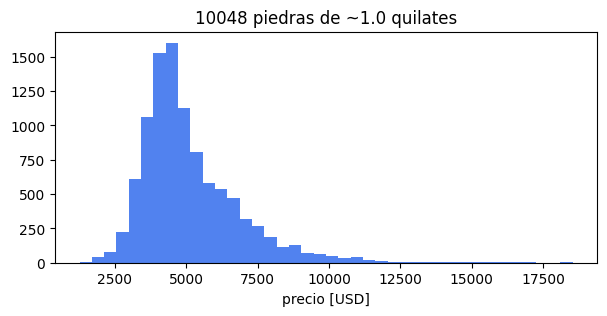

In [10]:
def donde_cae(quilates):
    parecidas = d[abs(d.carat - quilates) < 0.1]
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.hist(parecidas.price, bins=40, color="#2563EB", alpha=.8)
    ax.set_xlabel("precio [USD]")
    ax.set_title(f"{len(parecidas)} piedras de ~{quilates} quilates")
    return fig

# la funcion se prueba sola primero, como siempre
_ = donde_cae(1.0)
plt.show()

if GRADIO:
    gr.Interface(
        fn=donde_cae,
        inputs=gr.Slider(0.2, 3.0, value=1.0, step=0.1, label="Quilates"),
        outputs=gr.Plot(label="Precios de piedras similares"),
        title="Escalón 3 · Comparables").launch()

### El escalón 4: el tasador

Con los tres escalones vistos, el tasador deja de ser magia: más entradas,
y un modelo adentro. El prompt que usé:

```
CONTEXTO: tengo `tasador` (RandomForest entrenado), la lista `columnas`
con el orden del entrenamiento, y el DataFrame `d` certificado.

OBJETIVO: app de Gradio para la mesa de compra — quilates, corte, color,
claridad y x, y, z como entrada; el precio estimado en USD como salida.

RESTRICCIONES: controles en español con unidades; corte, color y claridad
como desplegables con los valores de `d`; launch(share=True).

CRITERIO: tasar una piedra en menos de 30 segundos sin ayuda.
```

**El detalle técnico que el agente debe resolver** (y donde muchos fallan):
la app recibe 7 valores, pero el modelo espera *todas* las columnas de
`get_dummies`, en su orden. La función de abajo lo maneja armando una tabla
con nombres — si se pasan números pelados, nadie revisa nada y el modelo
tasa basura sin avisar. Ese error silencioso es el más caro de servir
modelos.

In [11]:
def armar_fila(carat, cut, color, clarity, x, y, z, depth, table):
    '''Convierte las entradas del usuario en la fila EXACTA que el modelo
    espera: mismas columnas de get_dummies, mismo orden.'''
    fila = pd.DataFrame(0, index=[0], columns=columnas, dtype=float)
    for col, v in [("carat", carat), ("x", x), ("y", y), ("z", z),
                   ("depth", depth), ("table", table)]:
        fila[col] = v
    # las categorias: se enciende la columna que corresponde
    for pref, valor in [("cut", cut), ("color", color), ("clarity", clarity)]:
        col = f"{pref}_{valor}"
        if col in fila.columns:
            fila[col] = 1.0
    return fila


def tasar_v1(carat, cut, color, clarity, x, y, z):
    fila = armar_fila(carat, cut, color, clarity, x, y, z,
                      d.depth.median(), d.table.median())
    precio = float(tasador.predict(fila)[0])
    return f"USD {precio:,.0f}"


# la probamos ANTES de montar la app, con una piedra tipica
print("piedra tipica:", tasar_v1(0.7, "Ideal", "G", "SI1", 5.7, 5.7, 3.5))

piedra tipica: USD 2,389


In [12]:
# la app v1 -- en Colab, esta celda publica el link
try:
    import gradio as gr

    app = gr.Interface(
        fn=tasar_v1,
        inputs=[
            gr.Number(label="Quilates", value=0.7),
            gr.Dropdown(sorted(d.cut.unique()), label="Corte", value="Ideal"),
            gr.Dropdown(sorted(d.color.unique()), label="Color", value="G"),
            gr.Dropdown(sorted(d.clarity.unique()), label="Claridad", value="SI1"),
            gr.Number(label="Largo x [mm]", value=5.7),
            gr.Number(label="Ancho y [mm]", value=5.7),
            gr.Number(label="Profundidad z [mm]", value=3.5),
        ],
        outputs=gr.Textbox(label="Tasación"),
        title="Tasador de diamantes · v1",
        description="Ingrese las medidas de la piedra.")

    if EN_COLAB:
        app.launch(share=True)       # <- aqui aparece el link publico
    else:
        print("interfaz construida; en Colab esta celda abre el link")
except ImportError:
    print("gradio no esta en este entorno; en Colab ya viene listo")

gradio no esta en este entorno; en Colab ya viene listo


---

# 🎬 Paso 6 · Blindar — que no mienta

La app funciona. Ahora la prueba que nadie le hace a su propia app: pedirle
algo absurdo.

In [13]:
# la misma clase de fila que RECHAZAMOS en el paso 1: una piedra que no existe
print("piedra de 0 quilates y 0 mm:", tasar_v1(0.0, "Ideal", "G", "SI1",
                                               0.0, 0.0, 0.0))

piedra de 0 quilates y 0 mm: USD 397


**Tasó una piedra que no existe. Sin dudar. Sin avisar.**

El modelo no sabe qué es un diamante: sabe interpolar entre los casos que
vio, y si le dan un punto absurdo, interpola igual. Por eso una herramienta
seria lleva **contrato de entrada y salida**:

- **Entrada:** rangos válidos — que no se inventan: salen **del dato
  certificado**. Fuera de rango, la app **no tasa**: explica.
- **Salida:** no un número seco — un número **con banda**. Y la banda sale
  gratis: los 100 árboles no opinan lo mismo, y esa discrepancia es la
  incertidumbre (la misma idea de las bandas del Módulo 5).

El prompt que usé:

```
Mejora la app del tasador con un CONTRATO de entrada y salida:

ENTRADA:
- calcula los rangos válidos de carat, x, y, z DESDE el DataFrame
  certificado `d` (mínimo y máximo)
- si el usuario mete un valor fuera de rango, NO tases: muestra un
  mensaje claro que diga qué campo está mal y cuál es el rango aceptable

SALIDA:
- además del precio, la banda P10-P90 calculada con las predicciones de
  los árboles individuales (tasador.estimators_)
- formato: "USD 5.400 (banda: 4.900 a 6.100)"

CRITERIO DE ACEPTACIÓN:
- la piedra de 0 mm tiene que ser RECHAZADA con mensaje, no tasada
- una piedra normal se tasa igual que antes
```

In [14]:
# los rangos NO se inventan: salen del dato certificado
RANGOS = {c: (float(d[c].min()), float(d[c].max()))
          for c in ["carat", "x", "y", "z"]}


def tasar_v2(carat, cut, color, clarity, x, y, z):
    # 1) el contrato de entrada
    for nombre, valor in [("quilates", carat), ("largo x", x),
                          ("ancho y", y), ("profundidad z", z)]:
        clave = {"quilates": "carat", "largo x": "x",
                 "ancho y": "y", "profundidad z": "z"}[nombre]
        lo, hi = RANGOS[clave]
        if not (lo <= valor <= hi):
            return (f"NO SE PUEDE TASAR: {nombre} = {valor} esta fuera "
                    f"del rango conocido ({lo:g} a {hi:g}). "
                    f"Revise la medida o consulte a un tasador humano.")

    # 2) la tasacion, con la banda de los arboles
    fila = armar_fila(carat, cut, color, clarity, x, y, z,
                      d.depth.median(), d.table.median())
    votos = np.array([arbol.predict(fila.values)[0]
                      for arbol in tasador.estimators_])
    mediana = np.median(votos)
    p10, p90 = np.percentile(votos, [10, 90])
    return (f"USD {mediana:,.0f}   "
            f"(banda P10-P90: {p10:,.0f} a {p90:,.0f})")


print("piedra tipica: ", tasar_v2(0.7, "Ideal", "G", "SI1", 5.7, 5.7, 3.5))
print("piedra de 0 mm:", tasar_v2(0.0, "Ideal", "G", "SI1", 0.0, 0.0, 0.0))

piedra tipica:  USD 2,352   (banda P10-P90: 2,285 a 2,568)
piedra de 0 mm: NO SE PUEDE TASAR: quilates = 0.0 esta fuera del rango conocido (0.2 a 5.01). Revise la medida o consulte a un tasador humano.


La piedra absurda ahora es **rechazada con explicación**, y la normal sale
con su banda. Cada error conocido se volvió una prueba — así se blinda.

*(Para publicarla con interfaz: la misma celda de la app v1, cambiando
`fn=tasar_v1` por `fn=tasar_v2`.)*

**Y una honestidad final:** la banda P10–P90 promete atrapar el precio real
el 80 % de las veces — o sea que el 20 % de las veces **no** lo atrapa. Así
debe ser: vender certeza sería mentir.

---

# 🛠️ Su reto · La calculadora de riesgo  *(25 min)*

**EL CASO.** Su cliente es una **aseguradora marítima**. Para calibrar su
modelo de riesgo estudia el naufragio mejor documentado de la historia: los
**891 pasajeros del Titanic**. Un modelo mal calibrado tarifica mal todas
las pólizas a la vez.

**Lo que les pidió:** *«la calculadora de riesgo: perfil del pasajero, y me
devuelve su probabilidad de sobrevivir. Con la misma seriedad del tasador».*

**La única diferencia técnica con la demo:** esto es **clasificación**
(sobrevive: sí/no → probabilidad), no regresión. El bosque también la sabe:
`RandomForestClassifier` y `predict_proba`. Todo lo demás — los seis pasos —
es idéntico.

In [15]:
# el dato de SU reto, desde el repositorio del curso
pasajeros = pd.read_csv(DATOS + "pasajeros_titanic.csv")
print(f"{len(pasajeros)} pasajeros")
pasajeros.head(3)

891 pasajeros


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True


### Paso 1 · Certificar

Su prompt de revisión de calidad (el de siempre). Preguntas que su revisión
debe responder: ¿qué columnas tienen faltantes, y cuántos? ¿qué deciden
hacer con la edad? ¿hay columnas que **no deberían** entrar al modelo?

In [16]:
# ✍️ su revision de calidad

### Paso 2 · Entrenar

`RandomForestClassifier`, con el 20 % reservado **antes**. Decidan ustedes —
en el prompt — qué columnas entran. El objetivo a predecir es `survived`
(0 o 1).

In [17]:
# ✍️ su entrenamiento

### Paso 3 · Examinar

De cada 100 pasajeros del examen, ¿a cuántos clasifica bien?

> ⚠️ **La advertencia, sin más pistas:** si su modelo acierta **casi todo**,
> no celebren. Paren y desconfíen: los modelos honestos no son perfectos.
> Algo en sus columnas huele — encuéntrenlo.

In [18]:
# ✍️ su examen

### Pasos 4 y 5 · Guardar y servir

`joblib` para guardar. Y la calculadora en Gradio: los controles que un
agente de seguros llenaría (clase, sexo, edad...), y como salida la
**probabilidad** — no el veredicto. «74 de cada 100 como usted
sobrevivieron» le sirve a una aseguradora; un «sí» seco, no.

In [19]:
# ✍️ su app con link

### Paso 6 · Blindar

Los rangos, **desde su dato certificado**. La prueba de aceptación: una
edad de 500 años tiene que ser rechazada con mensaje, no calculada.

In [20]:
# ✍️ su blindaje

### Antes de la puesta en común

- ¿Qué encontraron al certificar, y qué decidieron con la edad?
- ¿Qué columnas le dieron al modelo — y quién las eligió: ustedes o el
  agente?
- ¿Qué acierto sacaron? ¿Alguien sacó casi 100 de 100? — cuéntenos qué
  columnas usó.
- ¿Su calculadora devuelve probabilidad o veredicto? ¿Cuál le sirve al
  cliente?

---

# Cierre

## Lo que vimos → lo que decidimos

| Lo que vimos | Lo que decidimos |
|---|---|
| 23 piedras físicamente imposibles | Certificar **antes** de entrenar, y avisar al dueño del dato |
| El modelo entrenó en 2 segundos | El modelo no es el trabajo: el flujo alrededor sí |
| R² impresionante, pero abstracto | El error se reporta **en la unidad del negocio**: dólares |
| La sesión de Colab se apaga | El modelo se **guarda como archivo**, con versión |
| El tasador tasó una piedra de 0 mm en USD 409 | **Contrato de entrada**: rangos desde el dato, rechazo con mensaje |
| Los 100 árboles no opinan lo mismo | Esa discrepancia es la **banda** — y se entrega siempre |
| La banda a veces no atrapa el precio real | Así debe ser: promete 80 %, cumple 80 % — la certeza no existe |

## Si se llevan una sola cosa

> **Un modelo no es el producto. El producto es la herramienta que lo
> envuelve: certificada, examinada y blindada.**

2 segundos de modelo, 2 horas de ingeniería alrededor. Esa proporción es la
real.

## Su proyecto

Lo de hoy es **la pieza central**: el flujo de seis pasos con su dato, la
app con link, y el error del agente que hayan cazado. Entrega hasta el
**jueves de la próxima semana**, equipos de hasta 3.

En la Clase 3: los peligros con nombre — qué se puede pegar en un chat de IA
y qué no, antes de que trabajen con datos de la empresa.

---

*Machine Learning for Petroleum Engineers Using Python* · SLB Ecuador / UDLA
· 2026